# London Airbnb Analysis — Exploratory Data Analysis

This notebook explores patterns in the cleaned listings data through visualisations.

We look at:
- Price distribution across London
- Most and least expensive neighbourhoods
- Room type breakdown and pricing
- Superhost vs regular host comparison
- Review score distribution

## 1. Import Libraries and Load Data

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [3]:
# Load the cleaned listings data
listings = pd.read_csv('../data/listings_clean.csv')

print("Listings loaded!")
print("Rows:", len(listings))
print("Columns:", len(listings.columns))

Listings loaded!
Rows: 61765
Columns: 73


/var/folders/2j/d77yjnh176bbf7pmhw8lt2zc0000gq/T/ipykernel_71754/3104505139.py:2: DtypeWarning: Columns (2,37,46,54) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('../data/listings_clean.csv')


## 2. Price Distribution

First we look at how prices are distributed across all London listings.
The raw data contains extreme outliers so we will remove listings over £1000 per night.

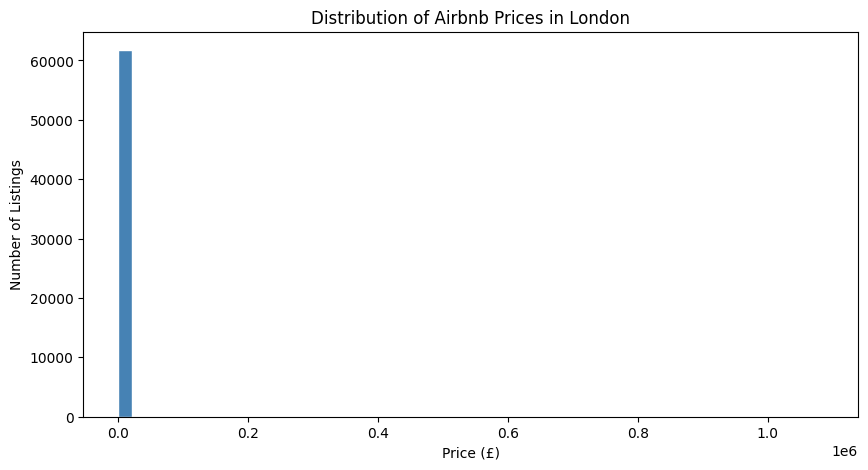

In [4]:
# Plot the distribution of prices
plt.figure(figsize=(10, 5))
plt.hist(listings['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Airbnb Prices in London')
plt.xlabel('Price (£)')
plt.ylabel('Number of Listings')
plt.show()

In [5]:
# Remove extreme price outliers - keep listings under £1000 per night
# Most realistic London Airbnb prices fall within this range
listings = listings[listings['price'] < 1000]

print("Listings after removing outliers:", len(listings))
print("Max price now: £", listings['price'].max())

Listings after removing outliers: 60953
Max price now: £ 999.0


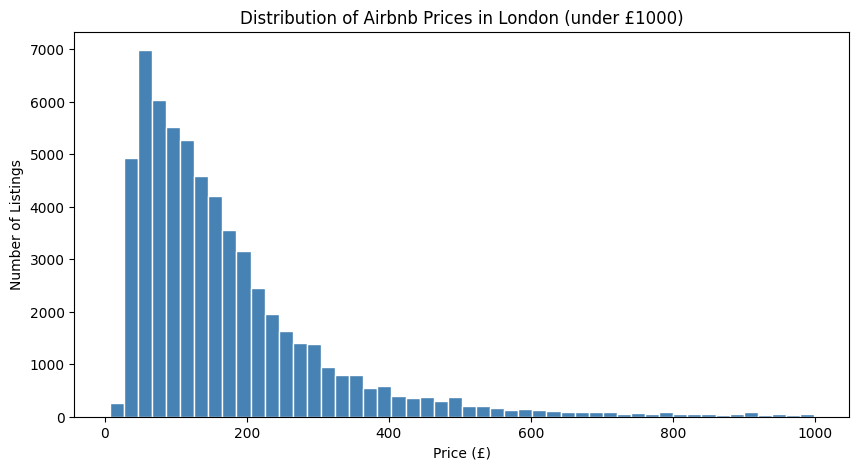

In [6]:
# Plot the distribution of prices again without outliers
plt.figure(figsize=(10, 5))
plt.hist(listings['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Airbnb Prices in London (under £1000)')
plt.xlabel('Price (£)')
plt.ylabel('Number of Listings')
plt.show()

## 3. Price by Neighbourhood

Which London boroughs are the most and least expensive on average?

In [7]:
# Calculate average price by neighbourhood
avg_price = listings.groupby('neighbourhood_cleansed')['price'].mean()

# Sort from most expensive to cheapest
avg_price = avg_price.sort_values(ascending=False)

print("Top 10 most expensive neighbourhoods:")
print(avg_price.head(10).round(2))

Top 10 most expensive neighbourhoods:
neighbourhood_cleansed
City of London            276.42
Kensington and Chelsea    269.44
Westminster               262.98
Camden                    192.92
1125                      179.00
Hammersmith and Fulham    178.63
Wandsworth                174.97
Islington                 173.60
Richmond upon Thames      171.57
Southwark                 151.37
Name: price, dtype: float64


In [8]:
# Check what the invalid neighbourhood looks like
print(listings[listings['neighbourhood_cleansed'] == '1125'])

       id listing_url scrape_id last_scraped source  \
14141 NaN         NaN       NaN          NaN      f   

                                                    name  \
14141  https://a0.muscache.com/im/pictures/user/3a51c...   

                                             description picture_url  host_id  \
14141  https://a0.muscache.com/im/pictures/user/3a51c...         1.0      2.0   

                 host_url  ... review_scores_checkin  \
14141  ['email', 'phone']  ...                   NaN   

      review_scores_communication review_scores_location review_scores_value  \
14141                         NaN                    NaN                 NaN   

      instant_bookable calculated_host_listings_count  \
14141              NaN                            NaN   

      calculated_host_listings_count_entire_homes  \
14141                                         NaN   

      calculated_host_listings_count_private_rooms  \
14141                                          NaN   



In [9]:
# Remove rows with invalid neighbourhood names
# Keep only rows where neighbourhood is a real London borough name
listings = listings[listings['neighbourhood_cleansed'] != '1125']

print("Listings remaining:", len(listings))

Listings remaining: 60952


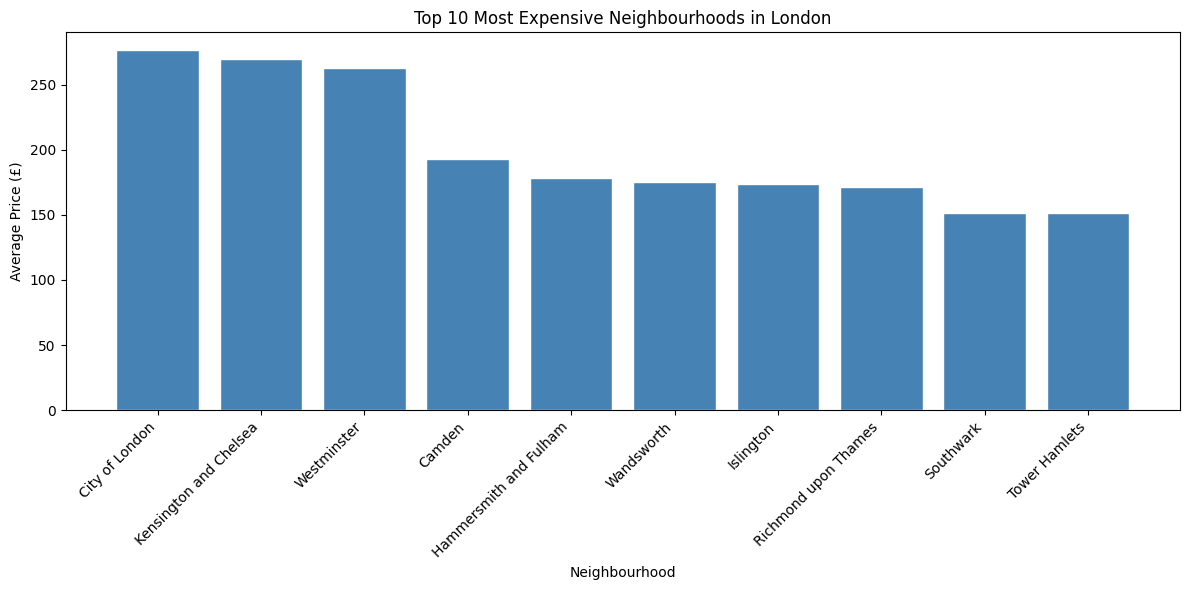

In [10]:
# Get top 10 most expensive neighbourhoods
avg_price = listings.groupby('neighbourhood_cleansed')['price'].mean()
avg_price = avg_price.sort_values(ascending=False)
top10 = avg_price.head(10)

# Plot as a bar chart
plt.figure(figsize=(12, 6))
plt.bar(top10.index, top10.values, color='steelblue', edgecolor='white')
plt.title('Top 10 Most Expensive Neighbourhoods in London')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Price (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Room Type Analysis

How do listings break down by room type and how does price vary between them?

In [11]:
# Count listings by room type
room_counts = listings['room_type'].value_counts()

print("Listings by room type:")
print(room_counts)

Listings by room type:
room_type
Entire home/apt    41596
Private room       19117
Shared room          184
Hotel room            54
730.0                  1
Name: count, dtype: int64


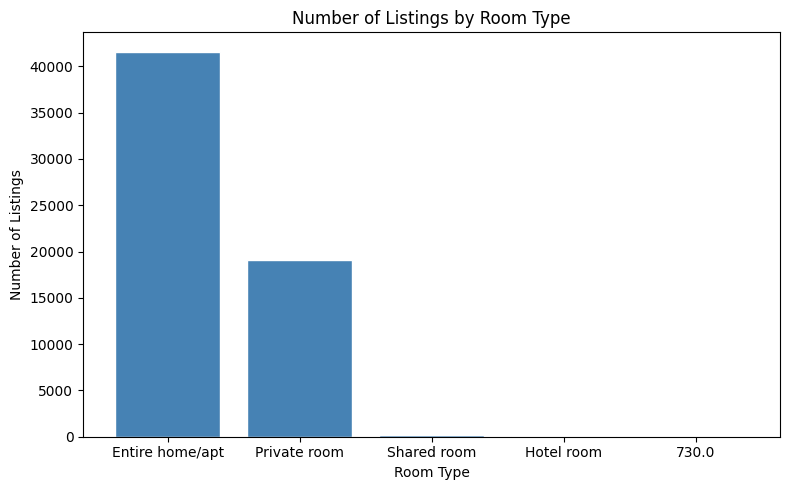

In [12]:
# Plot room type breakdown as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(room_counts.index, room_counts.values, color='steelblue', edgecolor='white')
plt.title('Number of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

In [13]:
# Remove rows with invalid room type values
valid_room_types = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
listings = listings[listings['room_type'].isin(valid_room_types)]

print("Listings remaining:", len(listings))
print("Room types:", listings['room_type'].unique())

Listings remaining: 60951
Room types: ['Private room' 'Entire home/apt' 'Hotel room' 'Shared room']


In [14]:
# Calculate average price by room type
avg_price_room = listings.groupby('room_type')['price'].mean()
avg_price_room = avg_price_room.sort_values(ascending=False)

print("Average price by room type:")
print(avg_price_room.round(2))

Average price by room type:
room_type
Entire home/apt    215.15
Hotel room         207.78
Private room        79.96
Shared room         58.92
Name: price, dtype: float64


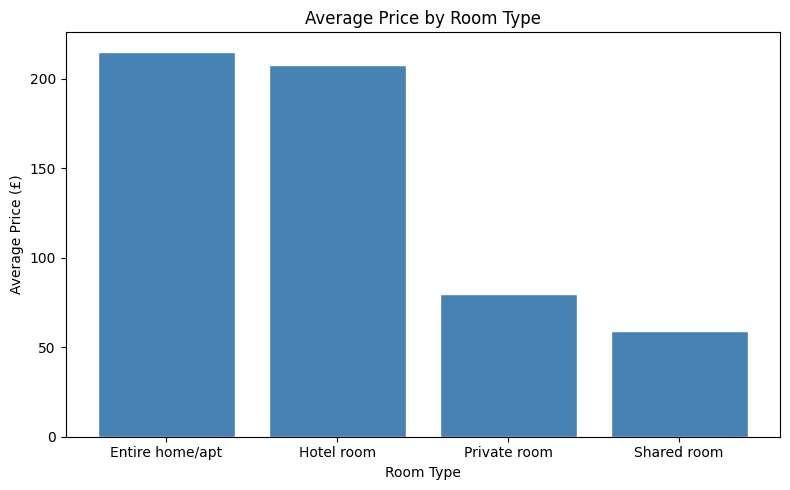

In [15]:
# Plot average price by room type
plt.figure(figsize=(8, 5))
plt.bar(avg_price_room.index, avg_price_room.values, color='steelblue', edgecolor='white')
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price (£)')
plt.tight_layout()
plt.show()

## 5. Superhost vs Regular Host

Do superhosts charge more than regular hosts?

In [16]:
# Calculate average price by superhost status
avg_price_host = listings.groupby('host_is_superhost')['price'].mean()

print("Average price by host type:")
print(avg_price_host.round(2))

Average price by host type:
host_is_superhost
f    168.04
t    185.34
Name: price, dtype: float64


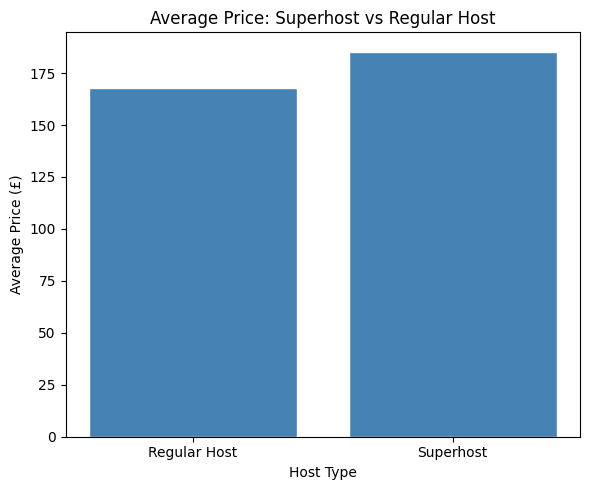

In [17]:
# Plot superhost vs regular host average price
plt.figure(figsize=(6, 5))
plt.bar(['Regular Host', 'Superhost'], avg_price_host.values, color='steelblue', edgecolor='white')
plt.title('Average Price: Superhost vs Regular Host')
plt.xlabel('Host Type')
plt.ylabel('Average Price (£)')
plt.tight_layout()
plt.show()

## 6. Review Scores

How are listings rated by guests? London Airbnbs tend to score very highly.

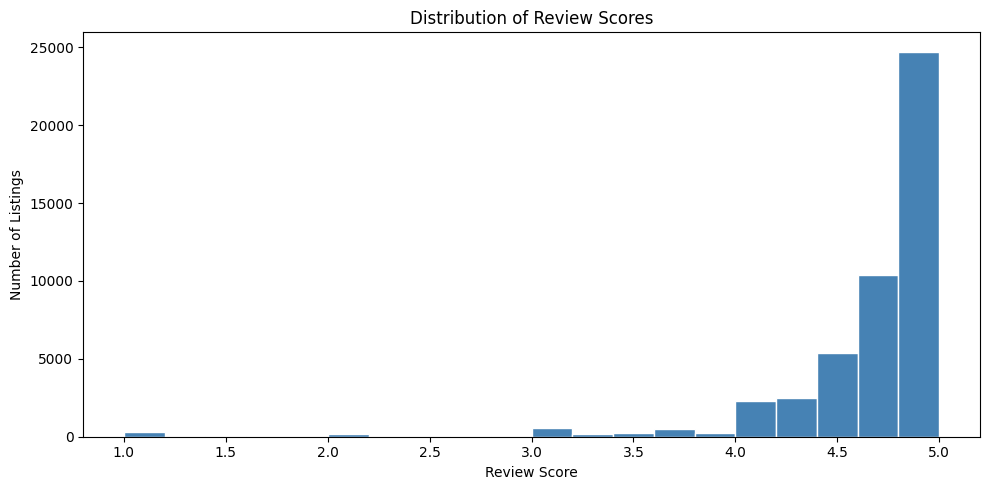

In [18]:
# Plot the distribution of review scores
plt.figure(figsize=(10, 5))
plt.hist(listings['review_scores_rating'].dropna(), bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

In [19]:
# Summary stats for review scores
print("Review score stats:")
print("Average:", round(listings['review_scores_rating'].mean(), 2))
print("Median:", listings['review_scores_rating'].median())
print("Lowest:", listings['review_scores_rating'].min())
print("Highest:", listings['review_scores_rating'].max())

Review score stats:
Average: 4.67
Median: 4.82
Lowest: 1.0
Highest: 5.0


## 7. Save Updated Data

Save the cleaned data with outliers removed ready for SQL analysis and modelling.

In [20]:
# Save the updated cleaned listings
listings.to_csv('../data/listings_clean.csv', index=False)

print("Updated listings saved!")
print("Final shape:", listings.shape)

Updated listings saved!
Final shape: (60951, 73)
